In [51]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

In [52]:
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight') # Options: 'ggplot', 'seaborn-v0_8-darkgrid', 'bmh'

plt.rcParams.update({
    'figure.facecolor': 'white',   # White background for the whole figure
    'axes.facecolor': 'tan',     # White background for the plotting area
    'savefig.facecolor': 'white',  # Ensures saved images also have a white background
    'figure.figsize': (5, 3),     # Standardize plot size
    'figure.dpi': 150,             # High resolution (crucial for crisp GitHub rendering)
    'font.family': 'sans-serif',   # Clean, modern font
    'axes.titlesize': 16,          # Larger title font
    'axes.labelsize': 14,          # Larger axis labels
    'axes.spines.top': False,      # Remove top border
    'axes.spines.right': False,    # Remove right border
    'lines.linewidth': 2.5,        # Thicker lines
    'grid.alpha': 0.5              # Softer grid lines
})

In [53]:
raw_data = pd.read_csv(
    "https://github.com/whitead/dmol-book/raw/main/data/curated-solubility-dataset.csv"
)
features_start_at = list(raw_data.columns).index("MolWt")
feature_names = raw_data.columns[features_start_at:]
features = feature_names.to_list()

In [54]:
raw_data.head(4)

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666


We will get the data of just our features and target variable. 

In [55]:
y = raw_data.Solubility
X = raw_data[features]
SMILES = raw_data[['Name', 'ID', 'SMILES']]
data = pd.concat([SMILES, X], axis=1)
data.shape

(9982, 20)

# **Table of Descriptors**

| Column Name | Description | Type |
|---|---|---|
| Solubility (**Target variable**)| Experimental aqueous solubility value (LogS) | float |
| MolWt | Molecular weight | float |
| MolMR | Molar refractivity | float |
| HeavyAtomCount | Number of non-H atoms | integer |
| NumHAcceptors | Number of H acceptors | integer |
| NumHDonors | Number of H donors | integer |
| NumHeteroatoms | Number of atoms not carbon or hydrogen | integer |
| NumValenceElectrons | Number of valence electrons | integer |

1) Molecular weight: Essentially the total weight of the molecule
2) Molecular refractivity: A measure of the polarizability for a entire mole of the molecule. 

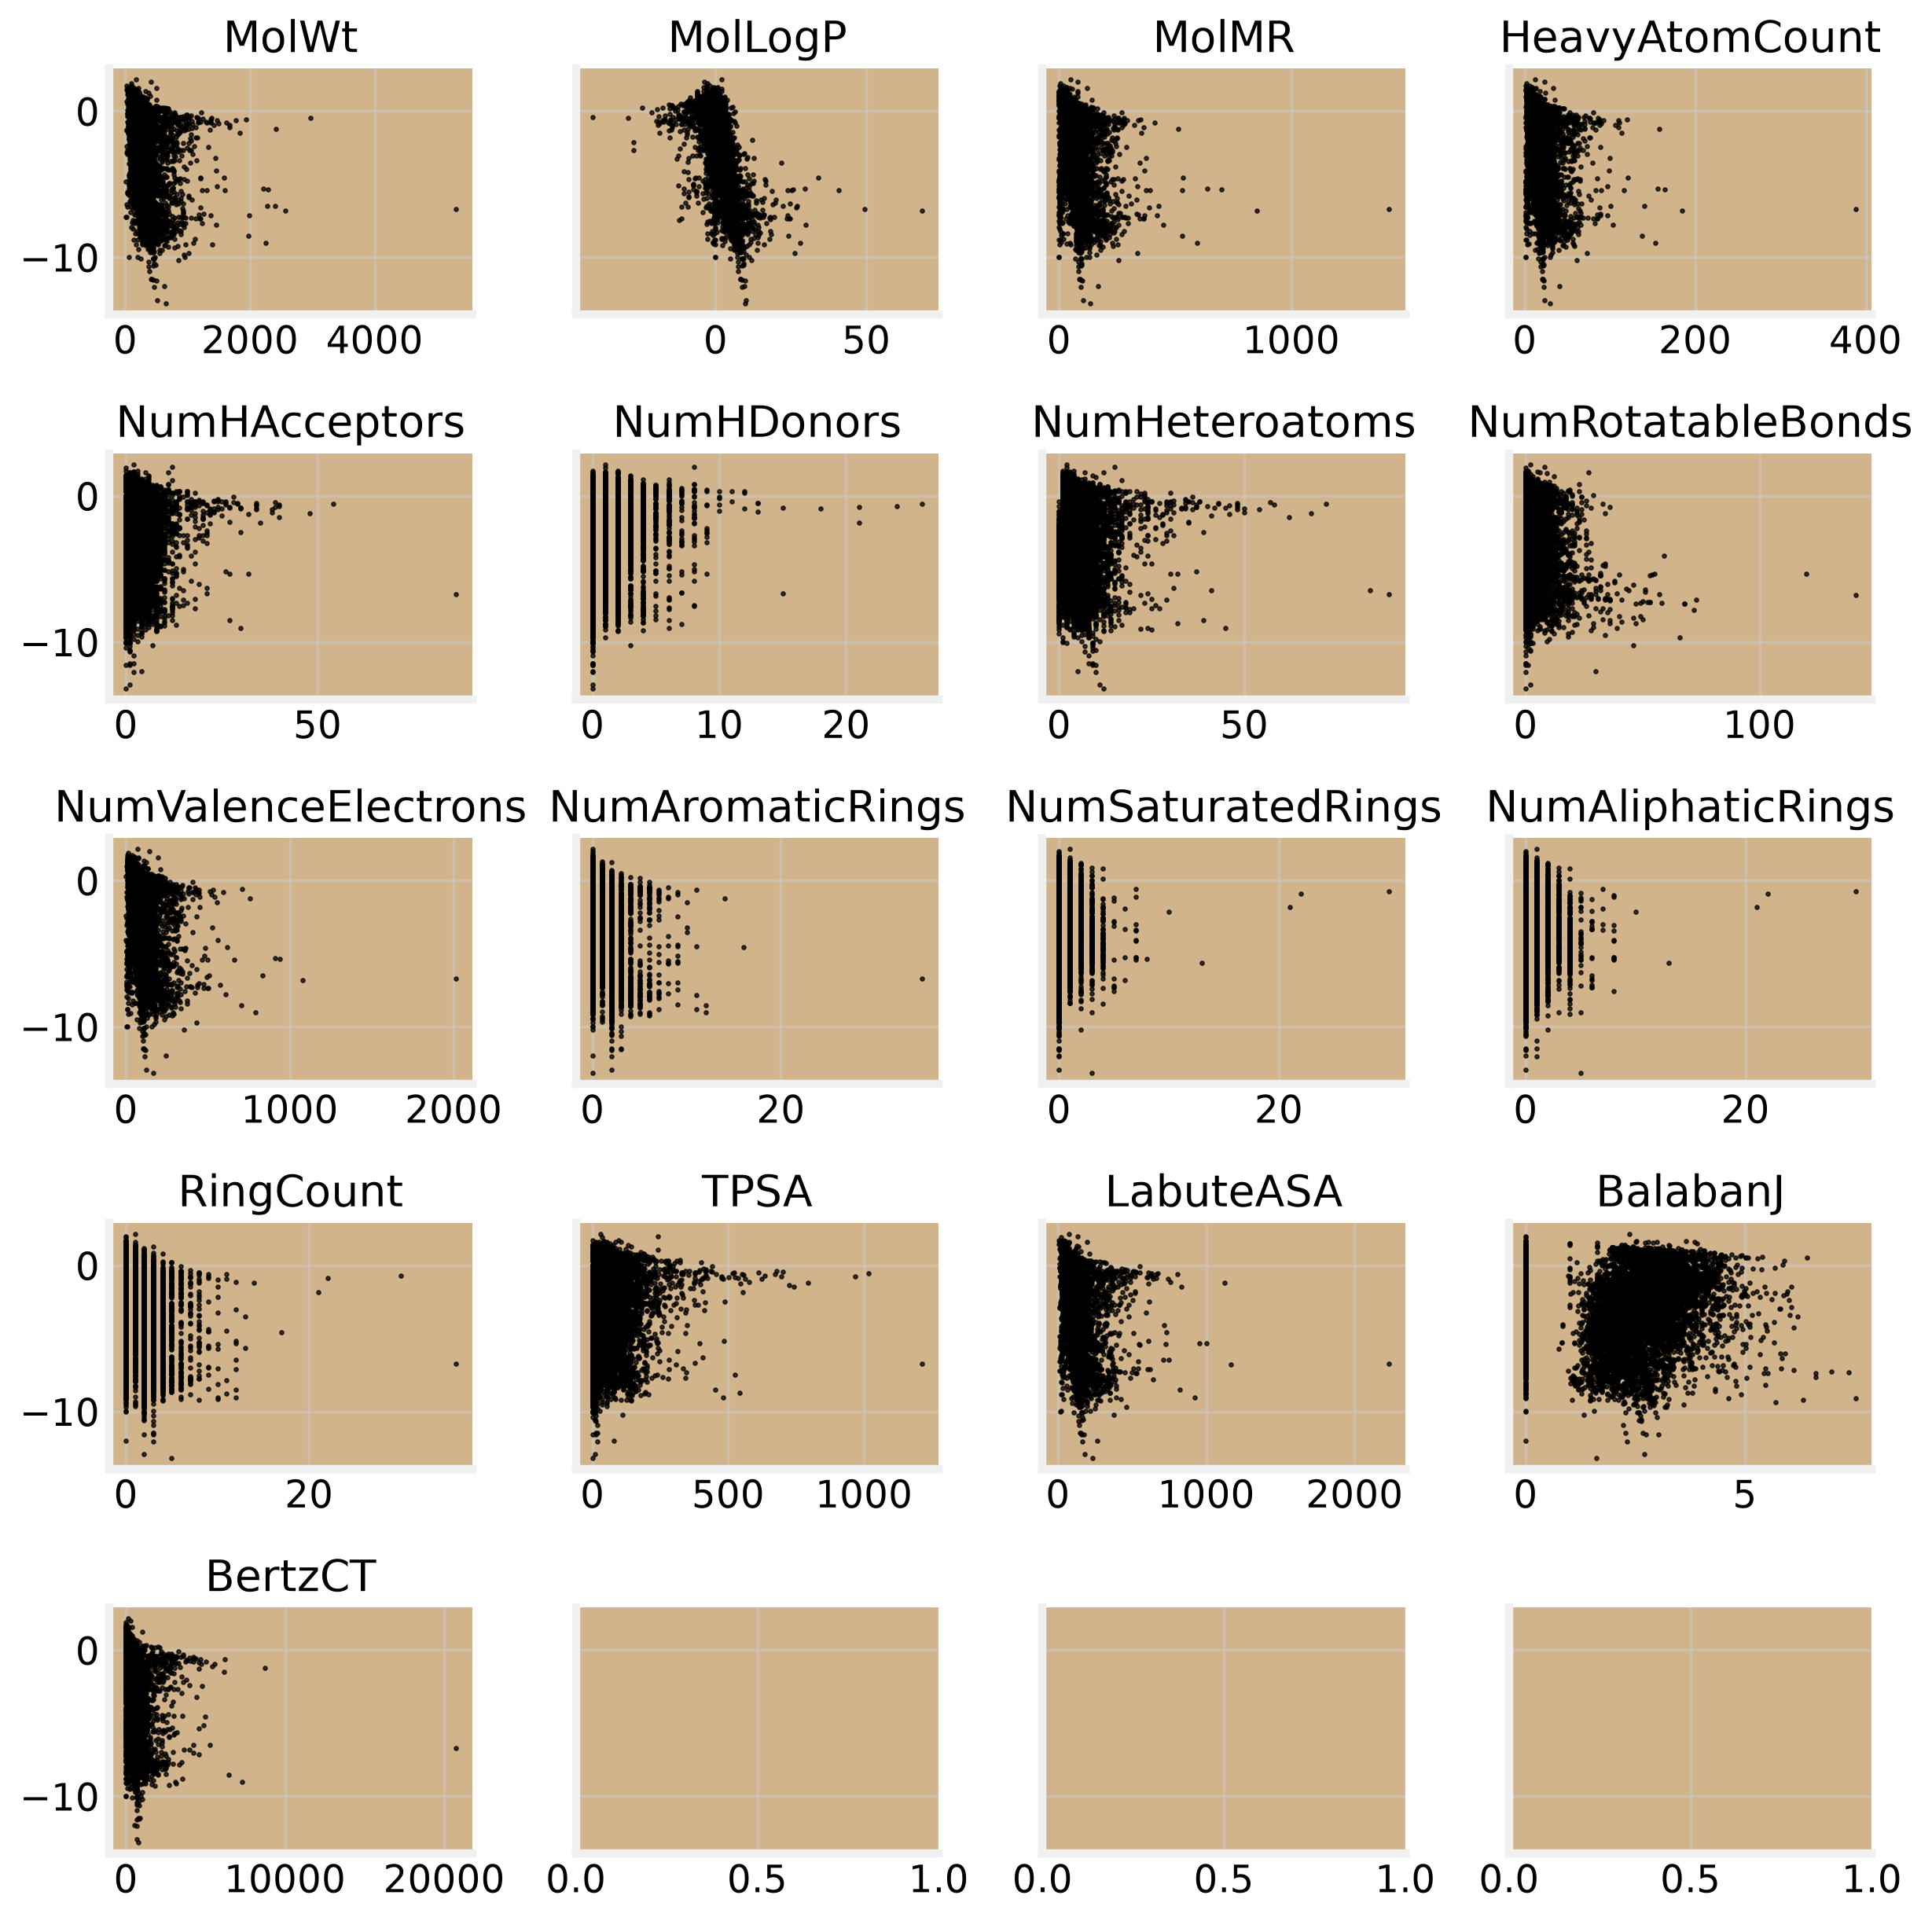

In [56]:
fig, axs = plt.subplots(5,4, sharey=True, figsize=(10, 10))

axs = axs.flatten()

for i in range(len(feature_names)):
    axs[i].scatter(data[feature_names[i]], y, color = 'black', alpha = 0.75, s = 2)
    axs[i].set_title(feature_names[i])

plt.tight_layout()
plt.show()

NumSaturatedRings and NumAliphaticRings > 10

In [57]:
smiles = data[data['NumSaturatedRings'] > 10]['SMILES']
smiles = smiles.values

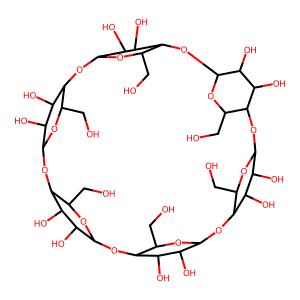

In [58]:
m = Chem.MolFromSmiles(smiles[1])
Draw.MolToImage(m)

## Histograms

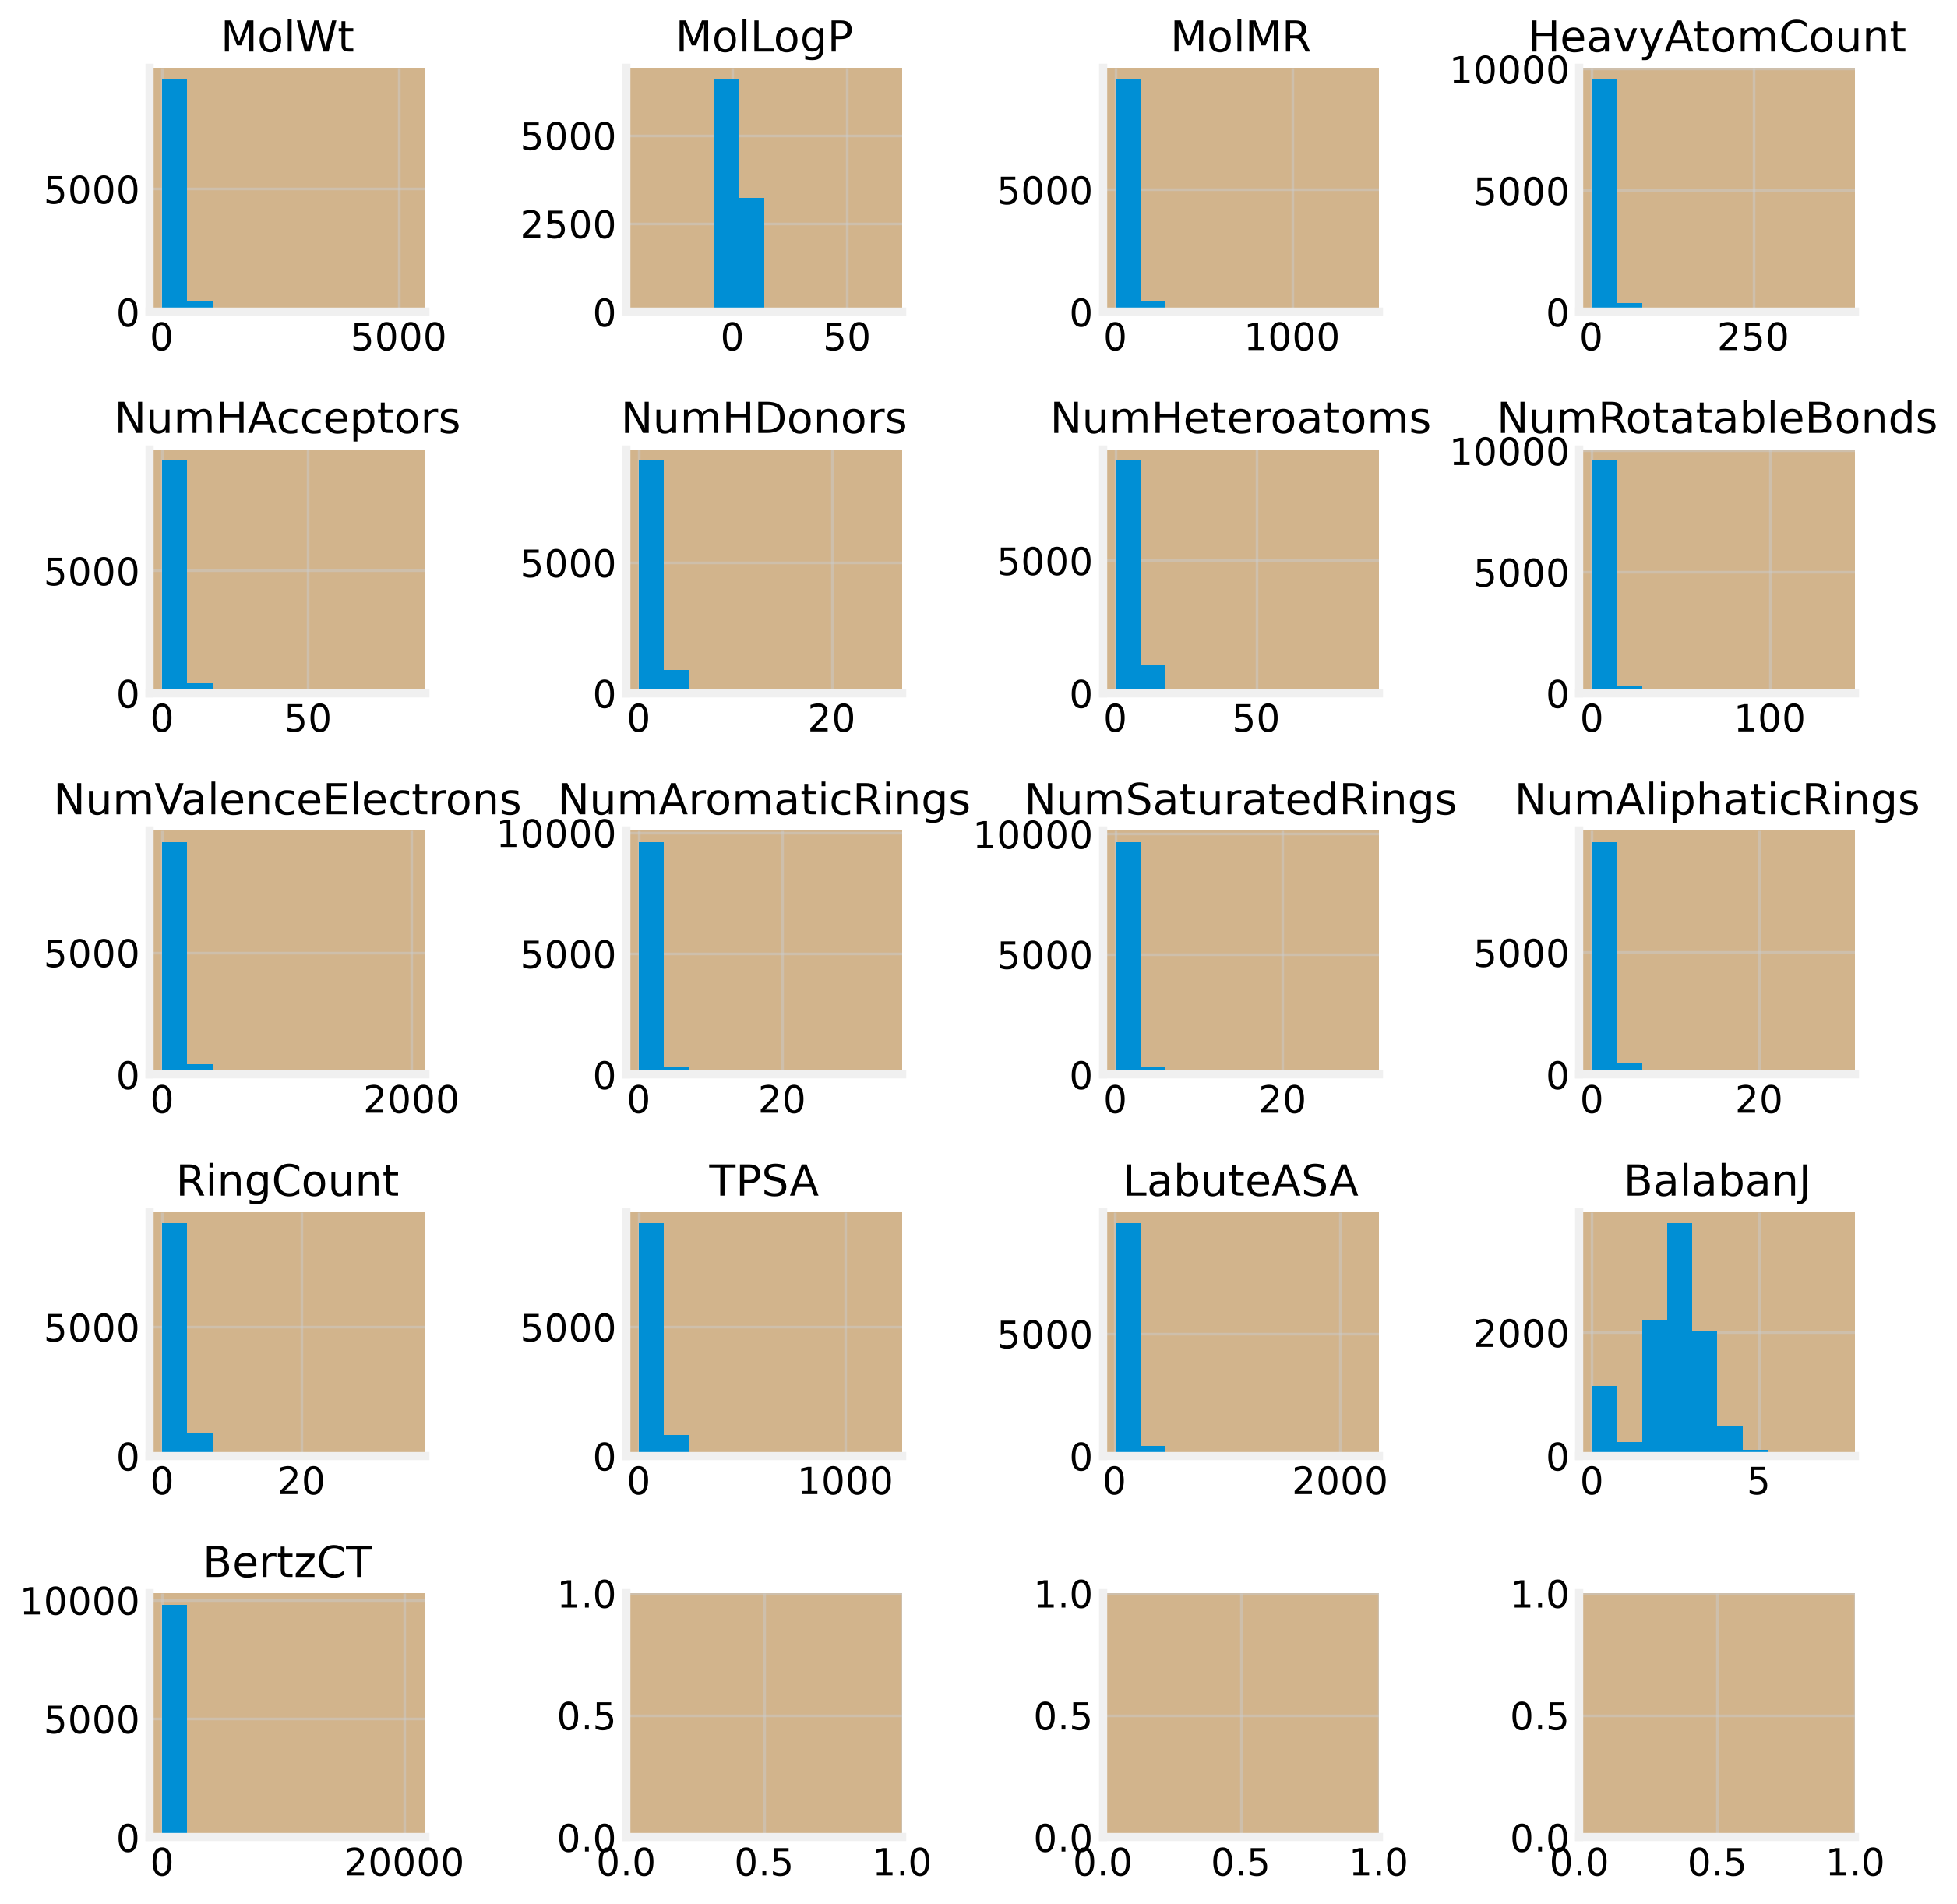

In [59]:
fig, axs = plt.subplots(5,4, figsize=(10, 10))

axs = axs.flatten()
epsilon = 1e-10


for i in range(len(feature_names)):
    axs[i].hist(data[feature_names[i]])
    axs[i].set_title(feature_names[i])

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/solubility-ml/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


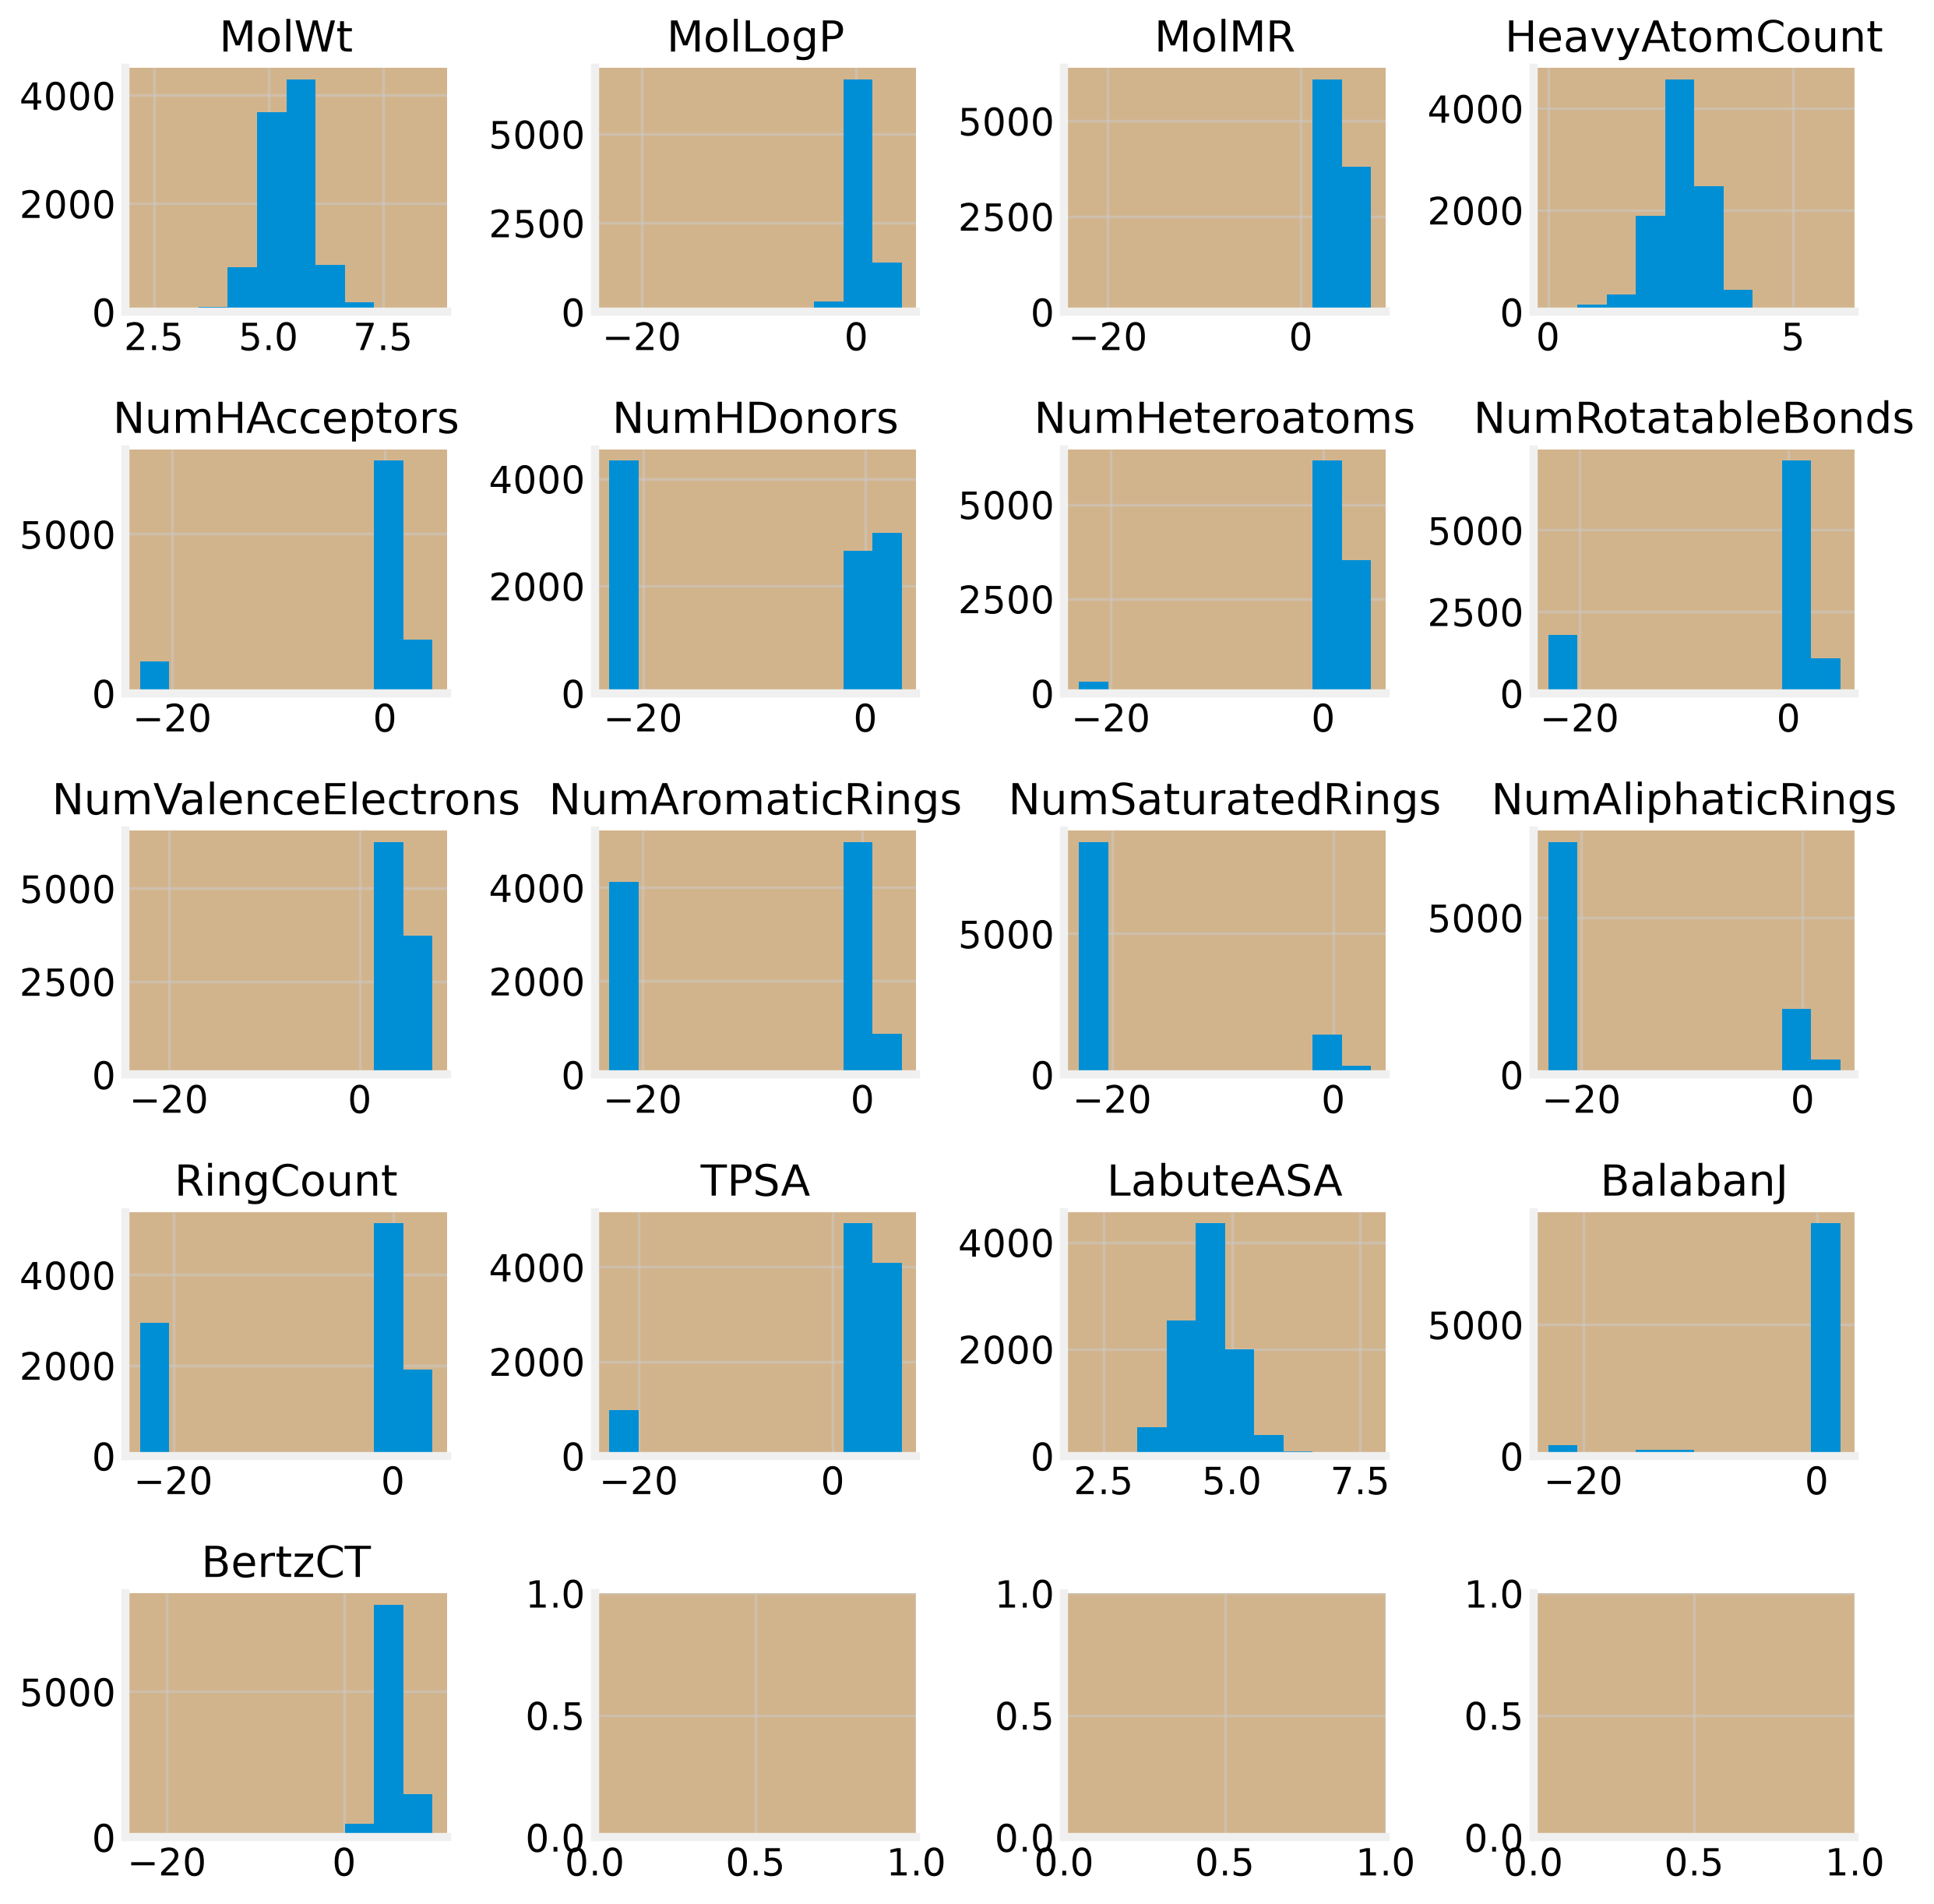

In [60]:
fig, axs = plt.subplots(5,4, figsize=(10, 10))

axs = axs.flatten()
epsilon = 1e-10


for i in range(len(feature_names)):
    axs[i].hist(np.log(data[feature_names[i]] + epsilon))
    axs[i].set_title(feature_names[i])

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Log Solubility')

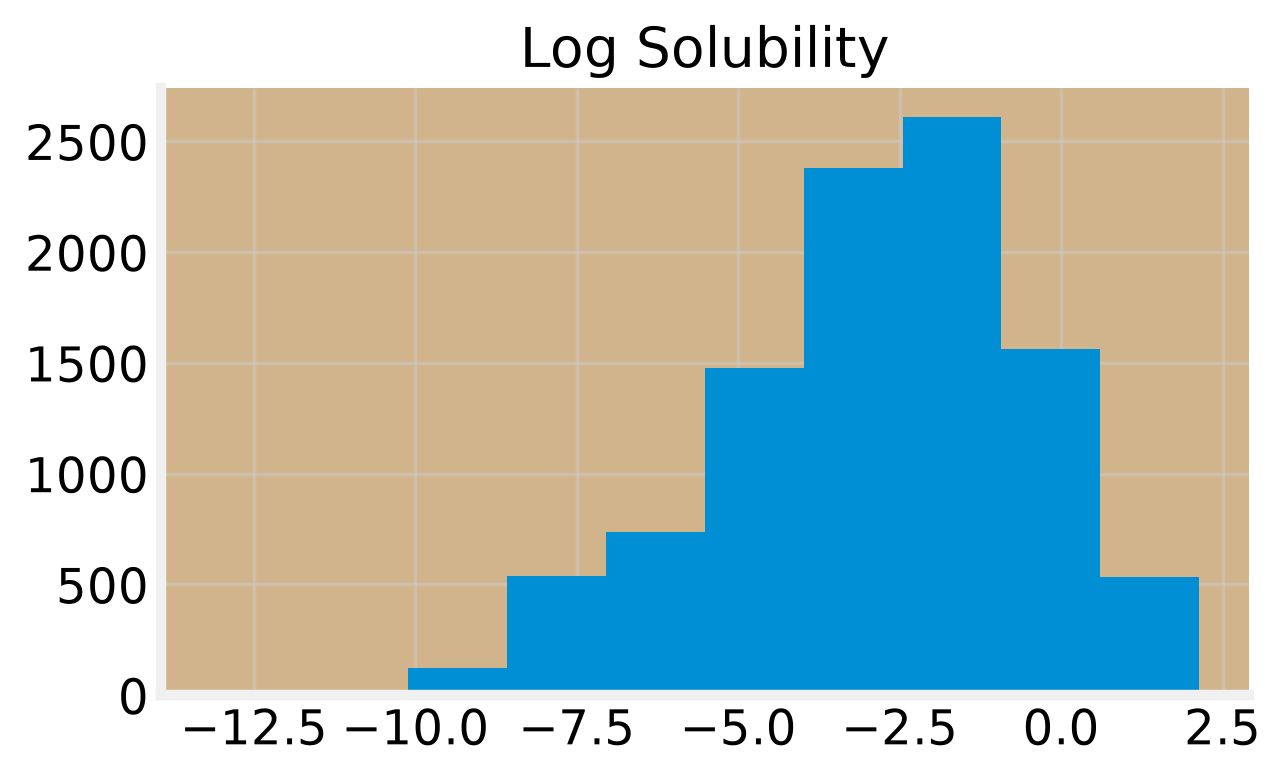

In [63]:
y.hist()
plt.title("Log Solubility")

# Appendix

## Full Table of Descriptors

| Column Name | Description | Type |
|---|---|---|
| ID | ID from source (also shows the source) | string |
| Name | Name of compound | string |
| InChI | The IUPAC International Chemical Identifier | string |
| InChIKey | Hashed form of InChI value | string |
| SMILES | SMILES representation of compound | string |
| Solubility | Experimental aqueous solubility value (LogS) | float |
| SD | Standard deviation of multiple occurrences | float |
| Occurrences | Number of occurrences of compound | integer |
| Group | Generated reliability group (G1, G2, G3, G4, G5) | string |
| MolWt | Molecular weight | float |
| MolLogP | Octanol-water partition coefficient | float |
| MolMR | Molar refractivity | float |
| HeavyAtomCount | Number of non-H atoms | integer |
| NumHAcceptors | Number of H acceptors | integer |
| NumHDonors | Number of H donors | integer |
| NumHeteroatoms | Number of atoms not carbon or hydrogen | integer |
| NumRotatableBonds | Number of rotatable bonds | integer |
| NumValenceElectrons | Number of valence electrons | integer |
| NumAromaticRings | Number of aromatic rings | integer |
| NumSaturatedRings | Number of saturated rings | integer |
| NumAliphaticRings | Number of aliphatic rings | integer |
| RingCount | Number of total rings | integer |
| TPSA | Topological polar surface area | float |
| LabuteASA | Labute's Approximate Surface Area | float |
| BalabanJ | Balaban's J index (graph index) | float |
| BertzCT | A topological complexity index of compound | float |